# 练习1

In [17]:
import pandas as pd
pd.set_option('display.unicode.east_asian_width', True)
df = pd.read_excel('产品订单信息表.xlsx')
df

,订单ID,性别,产品类型,消费金额
0,2022030801,男,手机,3500
1,2022030802,男,电脑,5500
2,2022030803,女,手机,7000
3,2022030804,女,手机,3500
4,2022030805,男,手机,3500
5,2022030806,女,电脑,5500
6,2022030807,男,电脑,11000
7,2022030808,女,手机,3500
8,2022030809,女,手机,10500
9,2022030810,女,电脑,5500


#### 使用交叉表分析'产品订单信息表.xlsx'文件中性别和产品类型的关系

In [18]:
df1 = pd.crosstab(index=df['性别'],columns=df['产品类型'])
df1

产品类型,手机,电脑
性别,,
女,6,3
男,3,3


#### 使用透视表分析其中性别、产品类型和总消费的关系

In [19]:
df2 = df.pivot_table(
    values='消费金额',
    index='性别',
    columns='产品类型',
    aggfunc= 'sum',
    margins=True,
    margins_name='总消费'
)
df2

产品类型,手机,电脑,总消费
性别,,,
女,35500,16500,52000
男,10500,22000,32500
总消费,46000,38500,84500


# 练习2

#### 尝试导入成绩单表信息，并计算作业成绩的偏度和峰度

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.unicode.east_asian_width', True)
df = pd.read_excel('成绩单.xlsx')
df

,学号,作业
0,222401,66.000000
1,222402,63.353333
2,222403,84.290000
3,222404,90.283333
4,222405,89.256667
5,222406,95.410000
6,222407,56.313333
7,222408,81.843333
8,222409,80.906667
9,222410,77.163333


In [21]:
df1 = df.pivot_table(
    index=df['作业'],
    aggfunc='count'
)
df1

,学号
作业,
52.553333,1
56.313333,1
61.053333,1
63.353333,1
66.000000,1
66.063333,1
66.420000,1
66.596667,1
66.666667,1


In [22]:
skewness = df['作业'].skew()
kurt = df['作业'].kurt()
print(f'偏度 {skewness}')
print(f'峰度 {kurt}')

偏度 -0.8869130392858492
峰度 0.44567791437496496


#### 尝试绘制数据的直方图

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

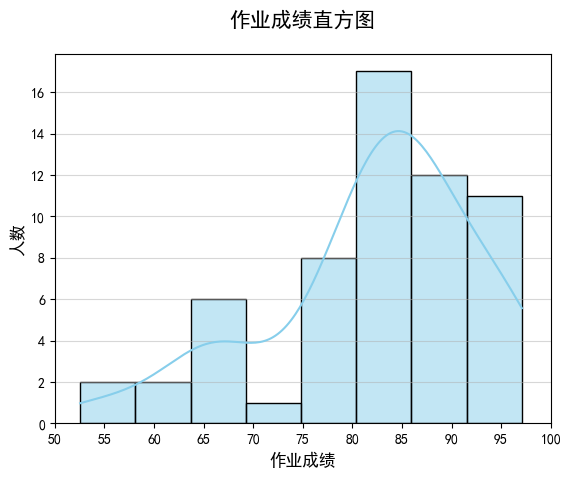

In [24]:
plt.rcParams['font.sans-serif'] = ['SimHei']

sns.histplot(data=df,x='作业',bins=8,kde=True,color='skyblue',edgecolor='black')
plt.title('作业成绩直方图',fontsize=15,pad=20)
plt.xlabel('作业成绩',fontsize=12)
plt.ylabel('人数',fontsize=12)
plt.grid(axis='y',alpha=0.5)
plt.xticks(range(50,101,5))
plt.show()
# 正偏态 期望>中位数>众数

# 练习3

#### 计算下面文件中各变量的相关系数，并利用费用和展现量列的数据绘制散点图

In [25]:
# 相关性 是否存在关系
import pandas as pd
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('expand_frame_repr', False)
df = pd.read_excel('营销和产品销量表.xlsx')
df

,日期,费用,展现量,点击量,订单金额,加购数,下单新客数,访问页面数,进店数,商品关注数
0,2020-02-01,1754.51,38291,504,2932.40,154,31,4730,94,7
1,2020-02-02,1708.95,39817,576,4926.47,242,49,4645,93,14
2,2020-02-03,921.05,39912,583,5413.60,228,54,4941,82,13
3,2020-02-04,1369.76,38085,553,3595.40,173,40,4551,99,6
4,2020-02-05,1460.02,37239,585,4914.80,189,55,5711,83,16
5,2020-02-06,1543.76,35196,640,4891.80,207,53,6010,30,6
6,2020-02-07,1457.93,33294,611,3585.50,151,37,5113,37,7
7,2020-02-08,1600.38,36216,659,4257.10,240,45,5130,78,11
8,2020-02-09,1465.57,36275,611,4412.30,174,47,4397,75,12
9,2020-02-10,1617.68,41618,722,4914.00,180,45,5670,86,5


In [26]:
df.corr()

,日期,费用,展现量,点击量,订单金额,加购数,下单新客数,访问页面数,进店数,商品关注数
日期,1.000000,0.674204,0.735885,0.858541,0.790643,0.704696,0.820946,0.849946,0.375041,0.192436
费用,0.674204,1.000000,0.856013,0.858597,0.625787,0.601735,0.642448,0.763320,0.650899,0.155748
展现量,0.735885,0.856013,1.000000,0.938554,0.728037,0.751283,0.756107,0.847017,0.697591,0.209990
点击量,0.858541,0.858597,0.938554,1.000000,0.854883,0.815858,0.863694,0.910142,0.585917,0.205446
订单金额,0.790643,0.625787,0.728037,0.854883,1.000000,0.813694,0.947238,0.803193,0.465630,0.279830
加购数,0.704696,0.601735,0.751283,0.815858,0.813694,1.000000,0.809087,0.776379,0.471594,0.312882
下单新客数,0.820946,0.642448,0.756107,0.863694,0.947238,0.809087,1.000000,0.842903,0.485570,0.361718
访问页面数,0.849946,0.763320,0.847017,0.910142,0.803193,0.776379,0.842903,1.000000,0.541397,0.327500
进店数,0.375041,0.650899,0.697591,0.585917,0.465630,0.471594,0.485570,0.541397,1.000000,0.393864
商品关注数,0.192436,0.155748,0.209990,0.205446,0.279830,0.312882,0.361718,0.327500,0.393864,1.000000


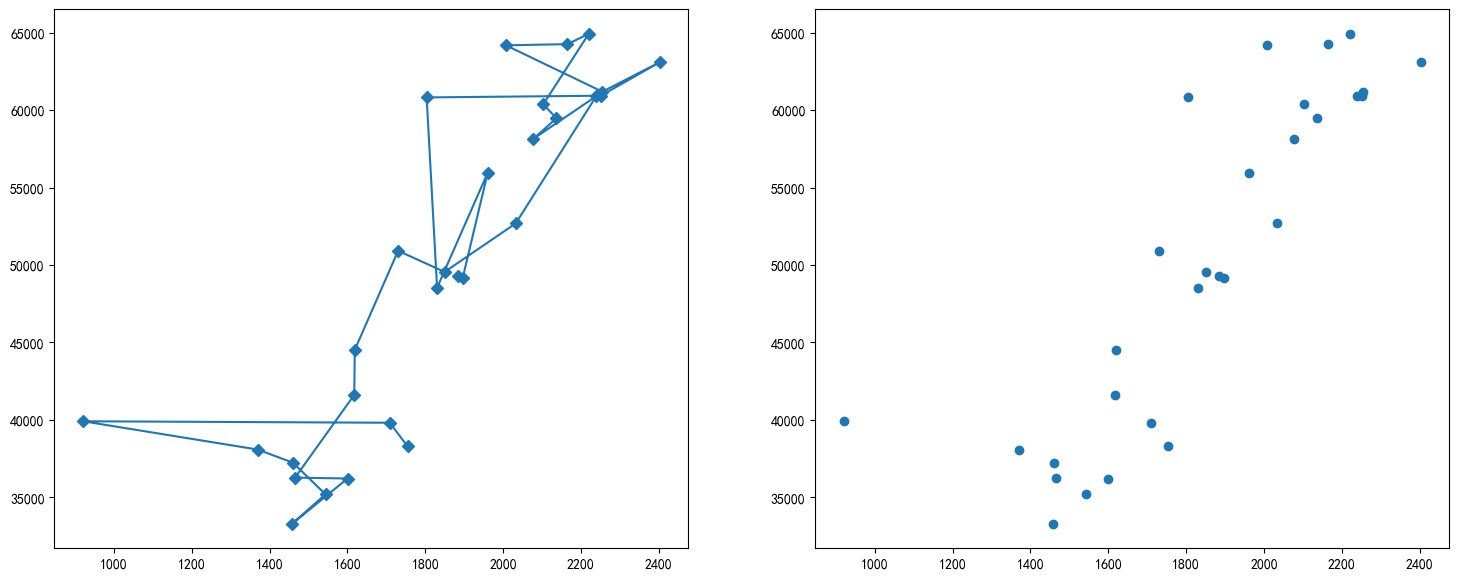

In [27]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(18,7))

ax[1].scatter(df['费用'],df['展现量'])
ax[0].plot(df['费用'],df['展现量'],marker='D') 
plt.show()

# 练习4

### 书114页案例，结合互联网广告智能投放数据进行分析，请分步骤完成案例

#### （1）导入“互联网广告智能投放数据.xlsx”文件中的数据

In [30]:
data = pd.read_excel('互联网广告智能投放数据.xlsx')
data

,用户ID,性别,年龄层次,消费等级,购物深度,城市等级,广告ID,商品类目ID,品牌ID,价格（元）,投放时间,渠道,是否点击
0,1,男,5,高,中,4,133190,37,169635,2560.0,2021-07-09 14:45:25,新闻平台,否
1,3,男,6,高,中,4,107685,4385,362586,128.0,2021-07-05 07:07:35,QQ,否
2,7,女,1,低,中,1,177553,7266,210257,13.0,2021-07-10 16:15:40,微信,否
3,7,女,1,低,中,1,177553,7266,210257,13.0,2021-07-05 21:07:17,微信,否
4,126,男,5,高,中,4,70764,10398,372532,5.0,2021-07-07 23:18:08,新闻平台,否
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24834,1141537,男,2,低,深,2,72780,1809,21354,168.0,2021-07-10 17:52:00,浏览器,否
24835,1141599,女,3,中,深,2,151710,8113,78538,319.0,2021-07-09 17:11:48,新闻平台,否
24836,1141630,女,3,中,深,2,57220,7882,3400,1160.0,2021-07-06 16:19:43,浏览器,否
24837,1141662,男,5,中,深,2,162818,6152,109219,880.0,2021-07-05 10:19:00,微博,否


#### （2）将投放时间转换成时间型数据，并提取其中的“hour"信息，替换原来的投放时间

In [32]:
data['投放时间'] = pd.to_datetime(data['投放时间']).dt.hour

#### （3）将数据按渠道分组，并以价格求和聚合计算每个渠道的总额；然后按总额降序排名；最后按排名升序排序

In [37]:
data1 = data.groupby('渠道').agg(
    {'价格（元）':'sum'}
)
data1['排名'] = data1['价格（元）'].rank(method='first',ascending=False)
data1.sort_values(by='排名',ascending=True,inplace=True)
data1

,价格（元）,排名
渠道,,
新闻平台,5634481.82,1.0
QQ,3094111.80,2.0
浏览器,2981624.82,3.0
微博,2831106.16,4.0
短视频平台,2621087.73,5.0
微信,2062663.38,6.0


#### （4）制作渠道和是否点击的交叉表，并按比例显示

In [40]:
pd.crosstab(index=data['渠道'],columns=data['是否点击'],margins_name='比例',margins=True)

是否点击,否,是,比例
渠道,,,
QQ,4397,96,4493
微信,2220,192,2412
微博,2214,1443,3657
新闻平台,6207,337,6544
浏览器,1985,2021,4006
短视频平台,3005,722,3727
比例,20028,4811,24839


#### （5）计算年龄层次、城市等级、价格和投放时间的相关系数

In [43]:
data[['年龄层次','城市等级','价格（元）','投放时间']].corr()

,年龄层次,城市等级,价格（元）,投放时间
年龄层次,1.000000,0.012548,0.013655,-0.002413
城市等级,0.012548,1.000000,-0.028131,-0.001319
价格（元）,0.013655,-0.028131,1.000000,0.004839
投放时间,-0.002413,-0.001319,0.004839,1.000000
